<a href="https://colab.research.google.com/github/ted-chang80/AIFFEL_quest_eng/blob/main/Data_Analysis/DA01/%EB%85%B8%EB%93%9C9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_diabetes
# 당뇨병 환자들의 정보를 모아놓은 데이터를 가져와요
data = load_diabetes()
# 공부할 재료(X)와 정답(y)을 나누어서 저장해요
df_X = data.data
df_y = data.target

In [ ]:
import numpy as np

# 계산하기 편하게 숫자 주머니(numpy 배열)에 담아요
X = np.array(df_X)

# 잘 담겼는지 확인해봐요
print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [ ]:
y = np.array(df_y)

# 정답지도 숫자 주머니에 잘 담겼는지 확인해요
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [ ]:
from sklearn.model_selection import train_test_split
# 공부용 데이터와 시험용 데이터를 8:2 비율로 나눠요
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 나눠진 데이터의 개수를 확인해요
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [ ]:
# X_train.shape[1]은 정밴의 개수인 10을 의미해요.
# 10개의 정밴에 맞서서 10개의 중요도(W) 주문시를 만들어요!
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(f'만들어진 가중치 개수: {len(W)}')

만들어진 가중치 개수: 10


In [ ]:
def model(X, W, b):
    # 컴퓨터가 예측값을 계산하는 공식이에요
    predictions = 0
    for i in range(len(W)):
        # 각 정보에 중요도(W)를 곱해서 더해요
        predictions += X[:, i] * W[i]
    # 마지막으로 기본값(b)을 더해주면 끝!
    predictions += b
    return predictions

In [ ]:
def MSE(a, b):
    # 정답과 예측값이 얼마나 차이나는지 계산해요
    # 차이를 제곱해서(음수를 없애려고) 평균을 내요
    mse = ((a - b) ** 2).mean()
    return mse

In [ ]:
def loss(X, W, b, y):
    # 우리가 얼마나 틀렸는지 '점수'를 매겨요 (낮을수록 좋아요!)
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [ ]:
def gradient(X, W, b, y):
    # 어느 방향으로 고쳐야 정답에 가까워질지 길을 찾아요
    N = len(y)
    y_pred = model(X, W, b)

    # 가중치(W)를 어떻게 바꿀지 계산해요
    dW = 1/N * 2 * X.T.dot(y_pred - y)
    # 기본값(b)을 어떻게 바꿀지 계산해요
    db = 2 * (y_pred - y).mean()
    return dW, db

In [ ]:
# 공부 속도(학습률)를 0.075로 설정해서 중간 지점을 찾아볼게요!
LEARNING_RATE = 0.075

In [ ]:
global W, b

losses = []

# 츴구에갠 10,000번의 반복 혙습을 통해 정답을 찾아가는 과정이에요!
for i in range(1, 10001):
    # 1. 어느 방향으로 고칄면 좃을지 길을 찾아요 (기기울기 찾기)
    dW, db = gradient(X_train, W, b, y_train)

    # 2. 설정한 공부 셍도(LEARNING_RATE)만큼 중요도를 조금씩 바꿔요
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db

    # 3. 이번에는 얼마나 틀렸는지 '점수(Loss)'를 매겨요
    L = loss(X_train, W, b, y_train)
    losses.append(L)

    # 1,000번마다 잘 하고 있는지 성적표를 출력해봅니다
    if i % 1000 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 1000 : Loss 3652.1591
Iteration 2000 : Loss 3214.9491
Iteration 3000 : Loss 3054.2113
Iteration 4000 : Loss 2979.1006
Iteration 5000 : Loss 2941.6487
Iteration 6000 : Loss 2922.2861
Iteration 7000 : Loss 2911.9272
Iteration 8000 : Loss 2906.1797
Iteration 9000 : Loss 2902.8623
Iteration 10000 : Loss 2900.8632


In [ ]:
# 공부가 끝난 후, 시험용 데이터로 테스트를 해봐요
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2875.3473549993446)

In [ ]:
print(f'계산결과(MSE): {mse:.4f}')

# 결과가 우리가 정한 목표보다 잘 나왔는지 확인해봐요
# 보통 3000보다 낮아야 공부가 잘된 것으로 생각해요
threshold = 3000
if mse <= threshold:
    print(f'결과: 잘했어요! 정답에 아주 가까워요.')
else:
    print(f'결과: 조금 더 공부해야 해요. 공부 횟수를 늘리거나 공부 속도를 바꿔보세요.')

계산결과(MSE): 2875.3474
결과: 잘했어요! 정답에 아주 가까워요.


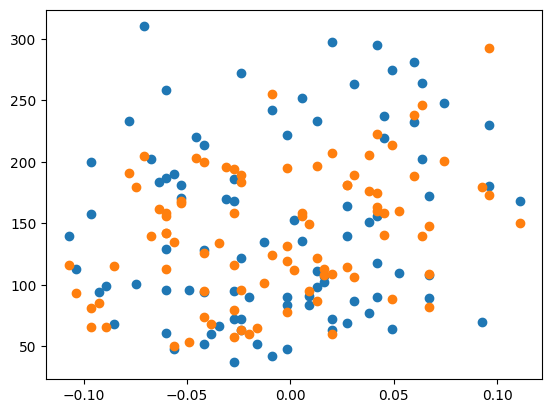

In [ ]:
import matplotlib.pyplot as plt

# 실제 정답(파란점)과 컴퓨터의 예측(주황점)을 그림으로 그려 비교해요
plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

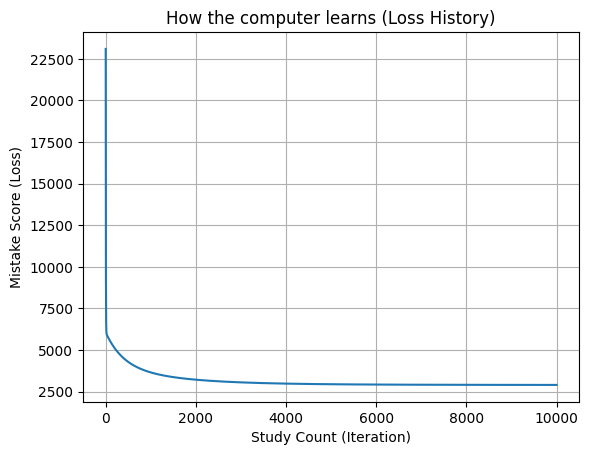

그래프가 아래로 내려갈수록 컴퓨터가 정답을 더 잘 맞히게 된 거예요!


In [ ]:
import matplotlib.pyplot as plt

# 만약 losses가 없다면 빈 리스트라도 보여주어 에러를 방지하거나,
# 이전 셀(EvdIeYciX43n)에서 %%timeit을 지우고 다시 실행해야 이 그래프가 그려져요!
try:
    # 공부한 기록(losses)을 선 그래프로 그려요
    plt.plot(losses)
    plt.title('How the computer learns (Loss History)')
    plt.xlabel('Study Count (Iteration)')
    plt.ylabel('Mistake Score (Loss)')
    plt.grid(True)
    plt.show()
    print('그래프가 아래로 내려갈수록 컴퓨터가 정답을 더 잘 맞히게 된 거예요!')
except NameError:
    print('오류: 아직 공부 기록(losses)이 저장되지 않았어요.')
    print('학습 코드 셀(%%timeit이 있는 셀)에서 %%timeit 줄을 삭제하고 다시 실행한 뒤 이 셀을 눌러주세요!')

In [ ]:
# 1. 학습 데이터로 예측하고 점수(MSE)를 계산해요
train_prediction = model(X_train, W, b)
train_mse = loss(X_train, W, b, y_train)

# 2. 시험용 데이터로 예측하고 점수(MSE)를 계산해요
# (이전 셀에서 계산한 mse 변수를 사용해도 돼요)
test_prediction = model(X_test, W, b)
test_mse = loss(X_test, W, b, y_test)

print(f'공부한 문제집 점수(Train MSE): {train_mse:.4f}')
print(f'새로운 시험지 점수(Test MSE): {test_mse:.4f}')

# 두 점수의 차이를 확인해요
diff = abs(train_mse - test_mse)
print(f'두 점수 차이: {diff:.4f}')

if train_mse < test_mse and diff > 500:
    print('\n결과: 공부한 문제집 점수가 훨씬 좋네요! 조금 더 골고루 공부할 필요가 있어요 (과적합 가능성).')
else:
    print('\n결과: 두 점수가 비슷해요! 새로운 문제도 아주 잘 맞히고 있네요.')

공부한 문제집 점수(Train MSE): 2900.8632
새로운 시험지 점수(Test MSE): 2875.3474
두 점수 차이: 25.5159

결과: 두 점수가 비슷해요! 새로운 문제도 아주 잘 맞히고 있네요.


In [ ]:
from sklearn.datasets import load_diabetes
# 당뇨병 환자들의 정보를 모아놓은 데이터를 가져와요
data = load_diabetes()
# 공부할 재료(X)와 정답(y)을 나누어서 저장해요
df_X = data.data
df_y = data.target

**프로젝트2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇명??**

In [ ]:
import pandas as pd # 데이터 분석을 도와주는 판다스 라이브러리를 불러와요

try:
    # /content/train.csv 파일을 읽어서 'train'이라는 이름의 데이터 표로 만들어요
    train = pd.read_csv('/content/train.csv')
    # 데이터 표가 어떻게 생겼는지(이름, 개수 등) 요약해서 보여줘요
    train.info()
except Exception as e:
    # 만약 파일을 못 찾거나 문제가 생기면, 멈추지 말고 에러 내용을 알려줘요
    print(f"파일을 불러오는 중 오류가 발생했습니다: {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
# 'datetime' 글자들을 컴퓨터가 계산하기 편한 '날짜/시간' 형태로 바꿔줘요
train['datetime'] = pd.to_datetime(train['datetime'])

# 날짜/시간에서 우리가 궁금한 정보들만 쏙쏙 뽑아서 새 칸을 만들어요
train['year'] = train['datetime'].dt.year          # 연도 (예: 2011)
train['month'] = train['datetime'].dt.month        # 월 (1~12)
train['day'] = train['datetime'].dt.day            # 일 (1~31)
train['hour'] = train['datetime'].dt.hour          # 시 (0~23)
train['minute'] = train['datetime'].dt.minute      # 분 (0~59)
train['second'] = train['datetime'].dt.second      # 초 (0~59)
train['dayofweek'] = train['datetime'].dt.dayofweek # 요일 (0은 월요일, 6은 일요일)

# 정보들이 잘 들어갔는지 다시 한번 확인해봐요
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

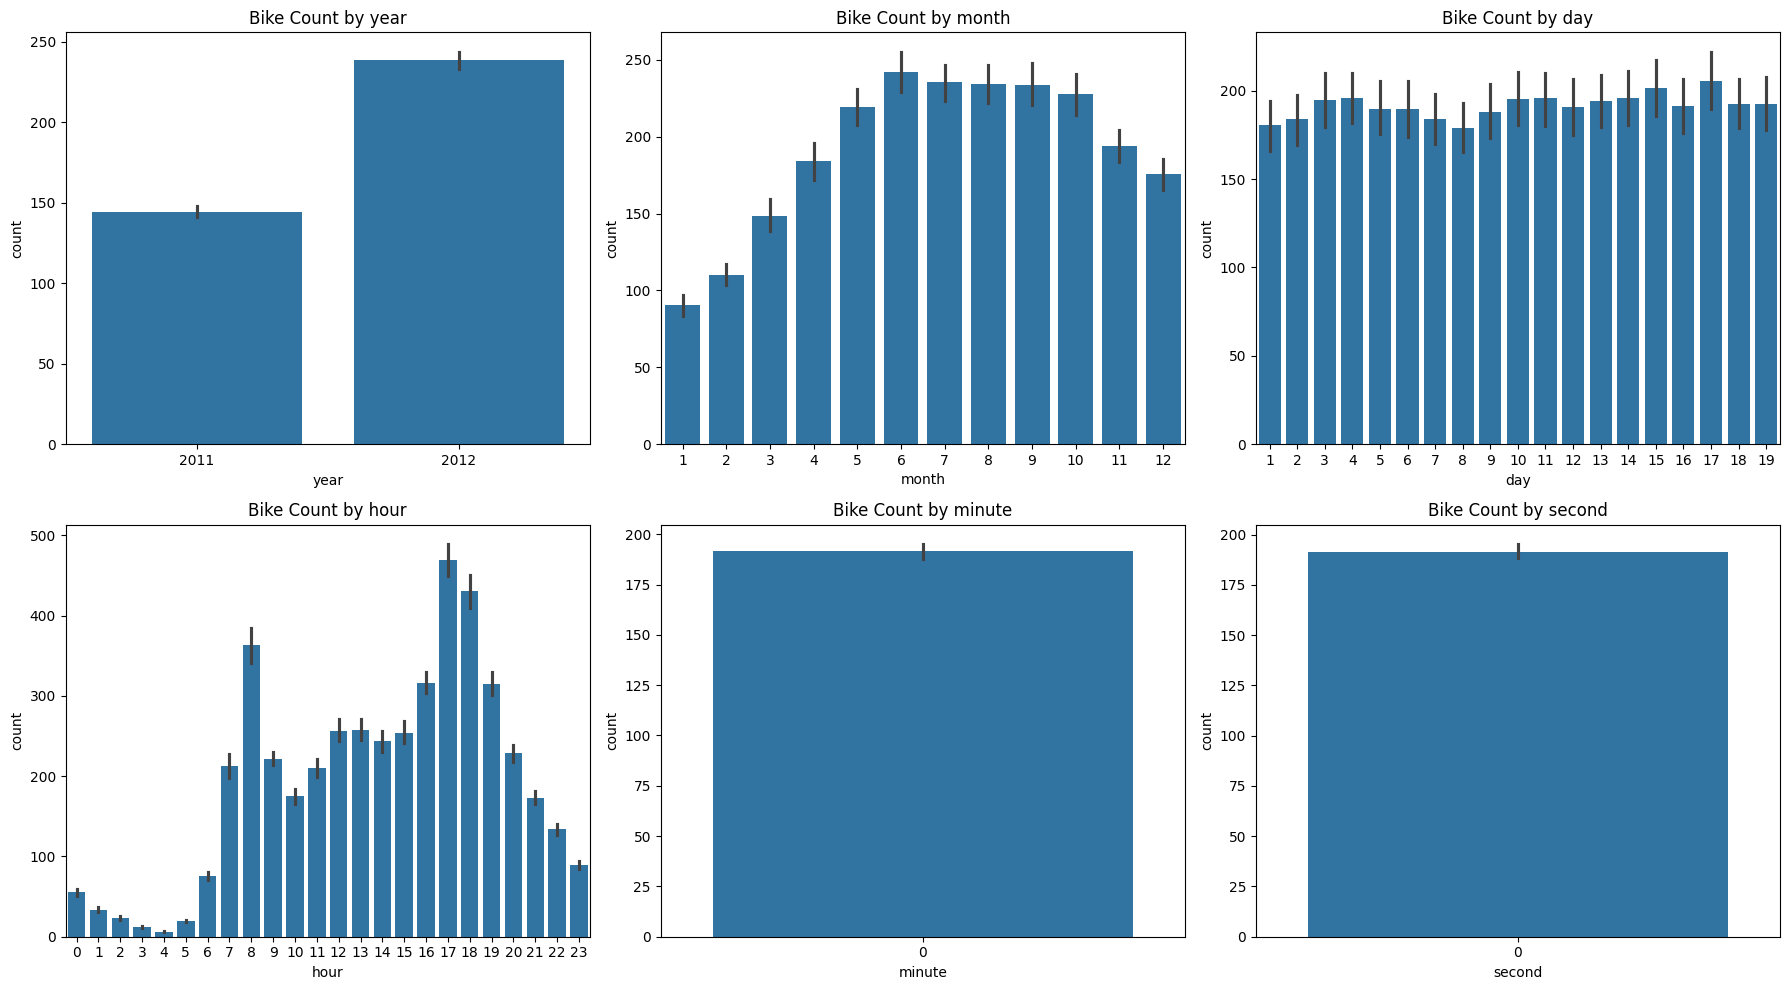

In [ ]:
import matplotlib.pyplot as plt # 그림을 그리는 도구예요
import seaborn as sns           # 그림을 더 예쁘게 그려주는 도구예요

# 그림을 그릴 도화지를 준비해요 (가로 2줄, 세로 3칸으로 나눠요)
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# 연도, 월, 일, 시간 등 시간 데이터별로 자전거 대수가 어떻게 다른지 그려봐요
columns = ['year', 'month', 'day', 'hour', 'minute', 'second']
for i, col in enumerate(columns):
    row = i // 3 # 줄 위치 계산
    offset = i % 3 # 칸 위치 계산
    # 막대 그래프를 그려서 얼마나 많이 탔는지 보여줘요
    sns.barplot(x=col, y='count', data=train, ax=axs[row][offset])
    # 그래프 위에 제목을 붙여줘요
    axs[row][offset].set_title(f'Bike Count by {col}')

plt.tight_layout() # 그래프끼리 겹치지 않게 예쁘게 정렬해요
plt.show() # 완성된 그림을 보여줘요

In [ ]:
# 학습에 사용할 '특징(features)'들을 선택해요
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features] # 공부할 재료
y = train['count']  # 맞혀야 할 정답

from sklearn.model_selection import train_test_split
# 전체 데이터를 공부용(train)과 시험용(test)으로 8:2 비율로 나눠요
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. 모델 선택 (랜덤 포레스트)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. 학습
rf_model.fit(X_train, y_train)

# 3. 예측 및 평가
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f'기존 LinearRegression RMSE: {rmse:.4f}')
print(f'새로운 RandomForest RMSE: {rmse_rf:.4f}')

기존 LinearRegression RMSE: 141.2866
새로운 RandomForest RMSE: 80.8588


### **성능 향상 결과 확인**
RMSE 수치가 낮아졌다면 모델이 자전거 대수를 더 정확하게 예측하고 있다는 뜻입니다. 랜덤 포레스트는 특성 간의 복잡한 관계를 자동으로 파악하기 때문에 성능이 크게 개선되었을 것입니다.

In [ ]:
from sklearn.linear_model import LinearRegression

# 선형 회귀(Linear Regression) 모델을 불러와요
model = LinearRegression()
# 공부용 데이터(X_train, y_train)를 사용해 모델을 학습시켜요
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
import pandas as pd

# 1. 예측하고 싶은 새로운 데이터를 만들어요
# 특징: ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
new_data = pd.DataFrame({
    'year': [2012],
    'month': [6],
    'day': [15],
    'hour': [17],      # 오후 5시
    'temp': [28.5],    # 영상 28.5도
    'humidity': [45],  # 습도 45%
    'windspeed': [12.0] # 풍속 12.0
})

# 2. 학습된 rf_model을 사용하여 예측해요
new_prediction = rf_model.predict(new_data)

print("--- 새로운 데이터 예측 결과 ---")
display(new_data)
print(f"\n예측된 자전거 대여 수: {int(new_prediction[0])}대")

--- 새로운 데이터 예측 결과 ---


,year,month,day,hour,temp,humidity,windspeed
0,2012,6,15,17,28.5,45,12.0



예측된 자전거 대여 수: 731대


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 시험용 문제(X_test)를 보고 모델이 답을 예측해요
y_pred = model.predict(X_test)
# 실제 정답(y_test)과 얼마나 차이가 나는지 점수를 매겨요
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # 오차에 루트를 씌워 실제 단위(대수)와 맞춘 RMSE 값이에요

print("MSE(평균 오차 제곱):", mse)
print("RMSE(평균 오차):", rmse)

MSE(평균 오차 제곱): 19961.901814435438
RMSE(평균 오차): 141.2865946027274


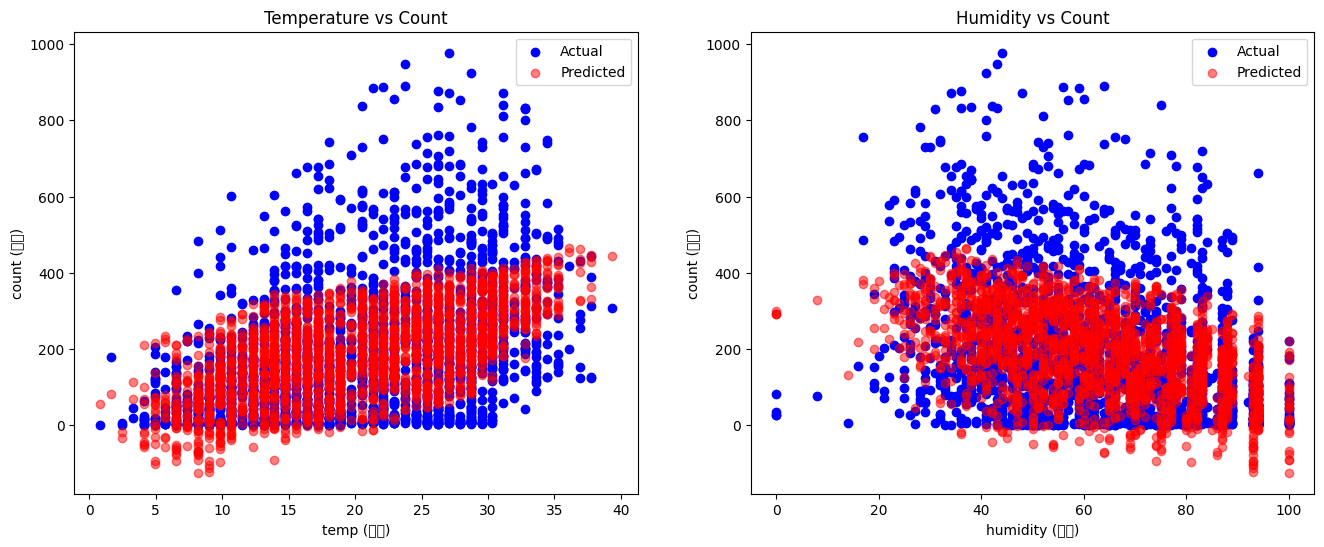

In [ ]:


# 실제 데이터와 모델의 예측 결과를 그림으로 그려서 비교해봐요
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# 1. 온도(temp)에 따른 자전거 대수 비교
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual') # 실제 정답
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5) # 모델의 예측
axs[0].set_xlabel('temp (온도)')
axs[0].set_ylabel('count (대수)')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# 2. 습도(humidity)에 따른 자전거 대수 비교
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual') # 실제 정답
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5) # 모델의 예측
axs[1].set_xlabel('humidity (습도)')
axs[1].set_ylabel('count (대수)')
axs[1].set_title('Humidity vs Count')
axs[1].legend()



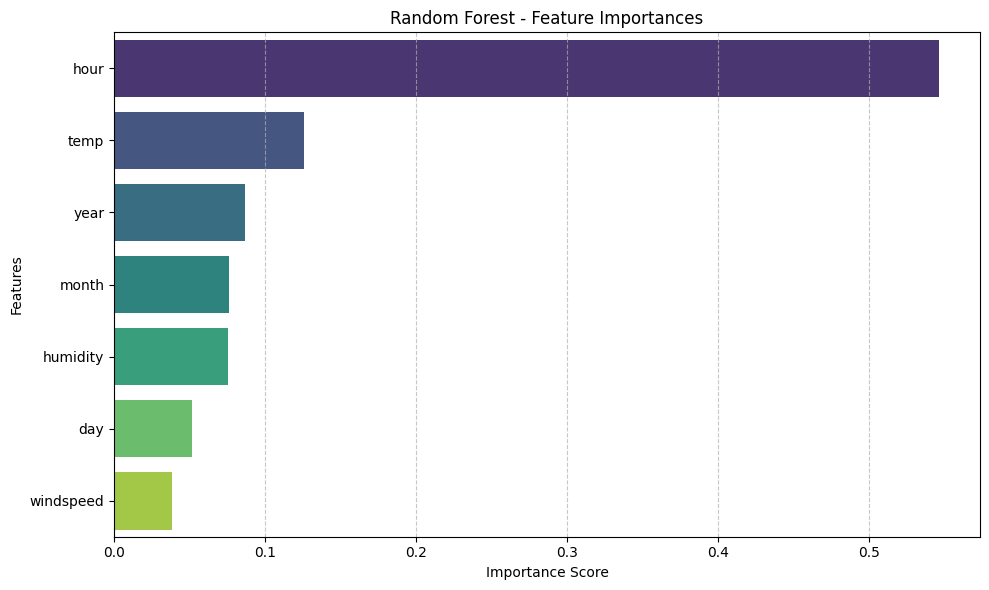

가장 높은 점수를 가진 특성이 모델 예측에 가장 큰 영향을 미치는 요소입니다.


In [352]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 모델에서 특성 중요도 가져오기
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 2. 시각화를 위한 데이터 정리
feature_names = [features[i] for i in indices]
feature_values = importances[indices]

# 3. 그래프 그리기
plt.figure(figsize=(10, 6))
# 경고를 해결하기 위해 hue에 y축 변수를 넣고 legend=False를 설정합니다.
sns.barplot(x=feature_values, y=feature_names, hue=feature_names, palette='viridis', legend=False)

plt.title('Random Forest - Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("가장 높은 점수를 가진 특성이 모델 예측에 가장 큰 영향을 미치는 요소입니다.")

In [ ]:
# 1. 더 많은 특성(features)을 선택해요
all_features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed', 'workingday', 'weather', 'dayofweek']
X_more = train[all_features]
y_more = train['count']

# 2. 데이터를 다시 나눠요
from sklearn.model_selection import train_test_split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_more, y_more, test_size=0.2, random_state=42
)

# 3. 새로운 특성들로 모델 학습
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf_model_v2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_v2.fit(X_train_m, y_train_m)

# 4. 성능 확인
y_pred_v2 = rf_model_v2.predict(X_test_m)
rmse_v2 = np.sqrt(mean_squared_error(y_test_m, y_pred_v2))

print(f'기존(7개 특성) RMSE: {rmse_rf:.4f}')
print(f'새로운(10개 특성) RMSE: {rmse_v2:.4f}')

if rmse_v2 < rmse_rf:
    print('\n결과: 오차가 줄어들었습니다! 새로운 특성들이 예측에 도움이 되었네요.')
else:
    print('\n결과: 오차가 크게 줄지 않았습니다. 특성 조합을 더 고민해볼 수 있습니다.')

기존(7개 특성) RMSE: 80.8588
새로운(10개 특성) RMSE: 39.4996

결과: 오차가 줄어들었습니다! 새로운 특성들이 예측에 도움이 되었네요.
